# Updated "How can I use code to read GeoTIFFs"

This notebook attempts to recreate the "How can I use code to read GeoTiffs?" [sic] Help Center Arcticle

https://nsidc.org/data/user-resources/help-center/how-can-i-use-code-read-geotiffs

The article reads data and plots MEaSUREs Greenland Ice Sheet Velocity InSAR data (NSIDC-0478).

The original help article uses data in the file `greenland_vel_mosaic200_2016_2017_vv_v2.tif`.  The most recent version of this file can be obtained from:

https://search.earthdata.nasa.gov/search/granules?p=C3291179132-NSIDC_CPRD&pg[0][v]=f&pg[0][id]=greenland_vel_mosaic500_2016_2017*&pg[0][gsk]=-start_date&g=G3291184653-NSIDC_CPRD&lat=71.5&long=-43.50586701434159&zoom=4.144198526269722

However, the code below uses `xarray` with `rioxarray` to read the data and then the `xarray` plotting methods to generate a plot.

I use the original colormap.  However, this colormap is not perceptually uniform and should likely be updated to a different colormap.

In [1]:
from pathlib import Path

import xarray as xr
import rioxarray

import cartopy.crs as ccrs

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # To create colormap

import cmocean

filepath = Path("./greenland_vel_mosaic500_2016_2017_vv_v02.1.tif")

### Load Data

In [2]:
ds = xr.open_dataset(filepath, engine="rasterio").squeeze()
ds

<xarray.Dataset> Size: 67MB
Dimensions:      (x: 3034, y: 5480)
Coordinates:
  * x            (x) float64 24kB -6.59e+05 -6.585e+05 ... 8.57e+05 8.575e+05
  * y            (y) float64 44kB -6.395e+05 -6.4e+05 ... -3.378e+06 -3.379e+06
    band         int64 8B 1
    spatial_ref  int64 8B ...
Data variables:
    band_data    (y, x) float32 67MB ...

### Define colormap

The commented code defines a colormap using code in the original help article.  This is probably not perceptually sequential.

A nice alternative is the `cmocean.cm.app` colormap.

In [11]:
import numpy as np

# vel = np.exp(np.linspace(np.log(1), np.log(3000), num=256))
# hue = np.arange(256)/255.0
# sat = np.clip(1./3 + vel/187.5, 0, 1)
# value = np.zeros(256) + 0.75
# hsv = np.stack((hue, sat, value), axis=1)
# rgb = mcolors.hsv_to_rgb(hsv)
# # Be sure the first color (the background) is white
# rgb[0,:] = 1
# cmap = mcolors.ListedColormap(rgb, name='velocity')

cmap = cmocean.cm.amp

### Generate Plot

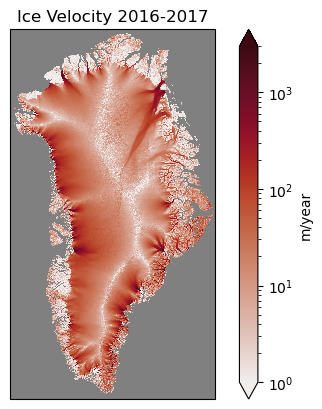

In [12]:
# Define WGS84 NSIDC North Polar Stereographic CRS
projection = ccrs.Stereographic(
    central_latitude=90., 
    central_longitude=-45., 
    true_scale_latitude=70.)

p = ds.band_data.plot(
    subplot_kws=dict(projection=projection, facecolor='grey',),
    norm=mcolors.LogNorm(vmin=1, vmax=3000, clip=True),
    cmap=cmap,
    cbar_kwargs=dict(label="m/year"),
)
p.axes.set_title("Ice Velocity 2016-2017");